In [1]:
import sys

sys.path.insert(0, "../src")

from datetime import datetime, timedelta
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [66]:
df = pd.read_csv("../data/VIX_5_min_2025-12-22.csv")
df["close_diff"] = df["close"].diff()
df["timestamp"] = pd.to_datetime(df["datetime"])
df["close_diff"] = df["close"].diff().fillna(0)
df.head()

,datetime,open,high,low,close,volume,close_diff,timestamp
0,2025-12-22 06:00:00,15.02,15.02,14.97,14.97,0,0.00,2025-12-22 06:00:00
1,2025-12-22 06:05:00,14.96,14.97,14.92,14.92,0,-0.05,2025-12-22 06:05:00
2,2025-12-22 06:10:00,14.92,14.98,14.92,14.98,0,0.06,2025-12-22 06:10:00
3,2025-12-22 06:15:00,14.97,14.99,14.97,14.99,0,0.01,2025-12-22 06:15:00
4,2025-12-22 06:20:00,14.98,14.98,14.96,14.97,0,-0.02,2025-12-22 06:20:00


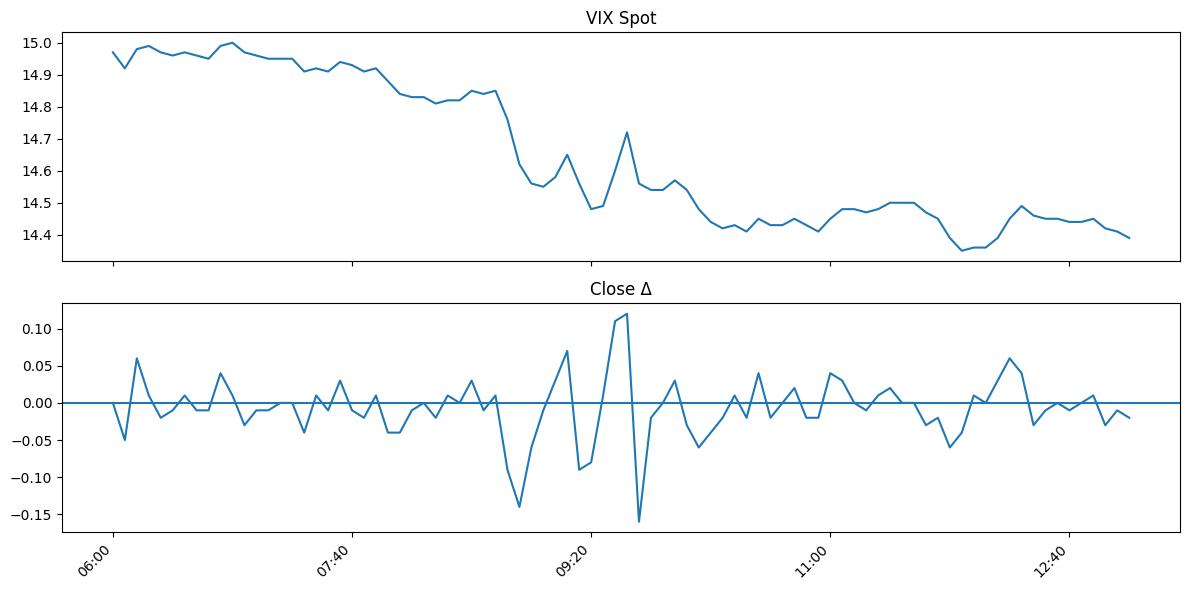

In [68]:
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(12, 6), sharex=True)

# Plot using real datetimes
ax1.plot(df["timestamp"], df["close"])
ax1.set_title("VIX Spot")

# --- Bottom subplot: close-to-close diff ---
ax2.plot(df["timestamp"], df["close_diff"])
ax2.axhline(0)
ax2.set_title("Close Δ")

# --- X-axis ticks (set ONCE, on bottom axis only) ---
tick_ts = df["timestamp"].iloc[::20]

ax2.set_xticks(tick_ts)
ax2.set_xticklabels(tick_ts.dt.strftime("%H:%M"), rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [70]:
opt_ch_df = pd.read_csv("../data/SPXW_exp2025-12-29_2025-12-22_15-03-20.csv")

In [77]:
list(opt_ch_df[opt_ch_df["gamma"] != 0]["gamma"])

[0.001,
 0.001,
 0.001,
 0.001,
 0.001,
 0.001,
 0.001,
 0.001,
 0.001,
 0.001,
 0.001,
 0.001,
 0.001,
 0.001,
 0.001,
 0.001,
 0.001,
 0.001,
 0.001,
 0.002,
 0.002,
 0.002,
 0.002,
 0.002,
 0.002,
 0.002,
 0.002,
 0.003,
 0.003,
 0.003,
 0.003,
 0.003,
 0.003,
 0.004,
 0.004,
 0.004,
 0.004,
 0.005,
 0.005,
 0.005,
 0.005,
 0.006,
 0.006,
 0.006,
 0.006,
 0.007,
 0.007,
 0.006,
 0.006,
 0.006,
 0.006,
 0.006,
 0.006,
 0.005,
 0.005,
 0.005,
 0.005,
 0.004,
 0.004,
 0.004,
 0.003,
 0.003,
 0.002,
 0.002,
 0.002,
 0.001,
 0.001,
 0.001,
 0.001,
 0.001,
 0.001,
 0.001,
 0.001,
 0.001,
 0.001,
 0.001,
 0.001,
 0.001,
 0.001,
 0.001,
 0.001,
 0.001,
 0.001,
 0.001,
 0.001,
 0.001,
 0.001,
 0.001,
 0.002,
 0.002,
 0.002,
 0.002,
 0.002,
 0.002,
 0.002,
 0.002,
 0.003,
 0.003,
 0.003,
 0.003,
 0.003,
 0.003,
 0.004,
 0.004,
 0.004,
 0.004,
 0.005,
 0.005,
 0.005,
 0.005,
 0.006,
 0.006,
 0.006,
 0.006,
 0.007,
 0.007,
 0.006,
 0.006,
 0.006,
 0.006,
 0.006,
 0.006,
 0.005,
 0.005,
 0.005,


In [87]:
symbol = "SPXW"
start_date = "2025-12-23"
start_dt = datetime.strptime(start_date, "%Y-%m-%d")
end_dt = start_dt + timedelta(days=7)
pattern = f"{symbol}_exp*.csv"
csv_files = sorted(Path("../data").glob(pattern))

In [92]:
len(csv_files)

580

In [108]:
files_by_date = {}
for csv_file in csv_files:
    try:
        # Parse filename: SYMBOL_expYYYY-MM-DD_YYYY-MM-DD_HH-MM-SS.csv
        parts = csv_file.stem.split("_")
        if len(parts) >= 4:
            exp_date = parts[1].replace("exp", "")
            exp_date = datetime.strptime(f"{exp_date}", "%Y-%m-%d")
            print("exp: ", exp_date)

            print(fetch_dt)
            # Only include files within our date range
            if exp_date <= end_dt and exp_date >= start_dt:
                date_key = exp_date
                if date_key not in files_by_date or exp_date > files_by_date[date_key][0]:
                    files_by_date[date_key] = (exp_date, csv_file)
        print("---------")
    except Exception:
        continue

exp:  2025-12-18 00:00:00
2025-12-23 09:08:28
---------
exp:  2025-12-18 00:00:00
2025-12-23 09:08:28
---------
exp:  2025-12-18 00:00:00
2025-12-23 09:08:28
---------
exp:  2025-12-18 00:00:00
2025-12-23 09:08:28
---------
exp:  2025-12-18 00:00:00
2025-12-23 09:08:28
---------
exp:  2025-12-18 00:00:00
2025-12-23 09:08:28
---------
exp:  2025-12-18 00:00:00
2025-12-23 09:08:28
---------
exp:  2025-12-19 00:00:00
2025-12-23 09:08:28
---------
exp:  2025-12-19 00:00:00
2025-12-23 09:08:28
---------
exp:  2025-12-19 00:00:00
2025-12-23 09:08:28
---------
exp:  2025-12-19 00:00:00
2025-12-23 09:08:28
---------
exp:  2025-12-19 00:00:00
2025-12-23 09:08:28
---------
exp:  2025-12-19 00:00:00
2025-12-23 09:08:28
---------
exp:  2025-12-19 00:00:00
2025-12-23 09:08:28
---------
exp:  2025-12-19 00:00:00
2025-12-23 09:08:28
---------
exp:  2025-12-19 00:00:00
2025-12-23 09:08:28
---------
exp:  2025-12-19 00:00:00
2025-12-23 09:08:28
---------
exp:  2025-12-19 00:00:00
2025-12-23 09:08:28
--

In [111]:
opt_chain_csv_path = "../data/SPXW_exp2025-12-29_2025-12-29_09-54-57.csv"

In [112]:
spxw_df = pd.read_csv(opt_chain_csv_path)
spxw_df.head()

# NOTES
- Understand Gamma Exposure (GEX): GEX measures how much dealer delta changes for a price move, calculated as Gamma × Open Interest × 100.
Calculate Call & Put GEX: For each strike price, calculate Call GEX (Call Gamma × OI × 100) and Put GEX (Put Gamma × OI × 100).

- Find Net GEX per Strike: Subtract Put GEX from Call GEX for each strike: Net GEX (Strike) = Call GEX (Strike) - Put GEX (Strike).

- Plot the Profile: Plot these Net GEX values against their strike prices to see the gamma profile.

- Identify Zero Gamma: The "Zero Gamma" level (or Flip Gamma) is the strike price where the cumulative Net GEX crosses from positive to negative or negative to positive. It's the inflection point in the market's gamma landscape. 

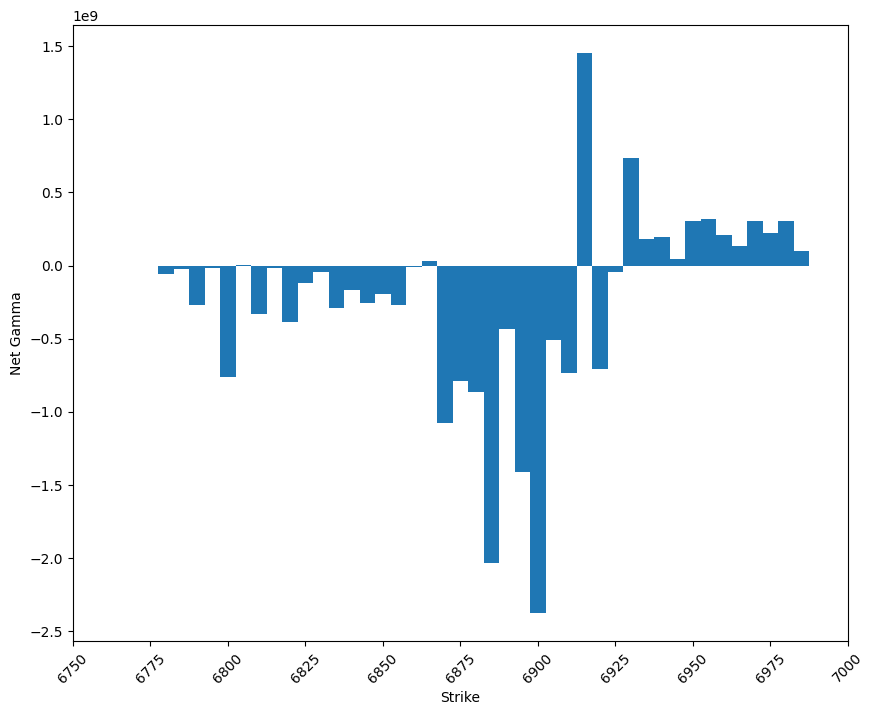

In [155]:
underyling_price = spxw_df.iloc[0]["underlying_price"]
call_opts = spxw_df[spxw_df["contract_type"] == "CALL"].reset_index(drop=True)
put_opts = spxw_df[spxw_df["contract_type"] == "PUT"].reset_index(drop=True)

call_strikes = call_opts["strike"].values

# call_gex = call_opts['gamma'] * call_opts['open_interest'] * 100
# put_gex = put_opts['gamma'] * put_opts['open_interest'] * 100
call_gex = call_opts["gamma"] * call_opts["open_interest"] * underyling_price**2
put_gex = put_opts["gamma"] * put_opts["open_interest"] * underyling_price**2

net_gamma = call_gex - put_gex

order = np.argsort(call_strikes)

call_strikes = call_strikes[order]
net_gamma = net_gamma.iloc[order].values

fig, axs = plt.subplots(figsize=(10, 8))

axs.bar(call_strikes, net_gamma, width=5)

axs.set_xlim(6750, 7000)

# ticks every 25 or 50 points
axs.set_xticks(np.arange(6750, 7000 + 1, 25))
axs.tick_params(axis="x", rotation=45)


axs.set_xlabel("Strike")
axs.set_ylabel("Net Gamma")
plt.show()

## Net Gamma by Strike

In [159]:
symbol = "SPXW"
start_date = "2025-12-29"
days_out = 10
data_dir = Path("../data")

start_dt = datetime.strptime(start_date, "%Y-%m-%d")
end_dt = start_dt + timedelta(days=days_out)

months = [start_dt.month, (start_dt.month % 12) + 1]
years = [start_dt.year, start_dt.year if start_dt.month < 12 else start_dt.year + 1]

csv_files = []
for m, y in zip(months, years):
    month_str = f"{y:04d}-{m:02d}"
    pattern = f"{symbol}_exp{month_str}*.csv"
    csv_files.extend(sorted(data_dir.glob(pattern)))

if not csv_files:
    raise ValueError(f"No option chain CSV files found for symbol {symbol} in {self.data_dir}")

files_by_expiration = {}
for csv_file in csv_files:
    try:
        parts = csv_file.stem.split("_")
        if len(parts) >= 4:
            exp_date_str = parts[1].replace("exp", "")
            exp_date = datetime.strptime(exp_date_str, "%Y-%m-%d")

            fetch_date = parts[2]
            fetch_time = parts[3]
            fetch_dt = datetime.strptime(f"{fetch_date}_{fetch_time}", "%Y-%m-%d_%H-%M-%S")

            if start_dt <= exp_date <= end_dt:
                if (
                    exp_date_str not in files_by_expiration
                    or fetch_dt > files_by_expiration[exp_date_str][0]
                ):
                    files_by_expiration[exp_date_str] = (fetch_dt, csv_file)
    except Exception:
        continue

if not files_by_expiration:
    raise ValueError(
        f"No option chain files found with expirations between {start_date} and {end_dt.strftime('%Y-%m-%d')}"
    )

latest_files = [file_info[1] for file_info in files_by_expiration.values()]

dfs = []
for csv_file in latest_files:
    df_temp = pd.read_csv(csv_file)

    if not df_temp.empty:
        dfs.append(df_temp)

In [183]:
underlying_price = dfs[0].iloc[0]["underlying_price"]
print(underlying_price)

net_gammas = []
for opt_chain in dfs:
    print(opt_chain.shape)
    call_opts = opt_chain[opt_chain["contract_type"] == "CALL"].reset_index(drop=True)
    put_opts = opt_chain[opt_chain["contract_type"] == "PUT"].reset_index(drop=True)

    call_strikes = call_opts["strike"].values

    net_gamma_df = pd.DataFrame()
    net_gamma_df["strike"] = call_strikes

    call_gex = call_opts["gamma"] * call_opts["open_interest"] * underyling_price**2
    put_gex = put_opts["gamma"] * put_opts["open_interest"] * underyling_price**2

    net_gamma_df["net_gamma"] = call_gex - put_gex
    net_gammas.append(net_gamma_df)

net_gamma = (
    pd.concat(net_gammas, ignore_index=True).groupby("strike", as_index=False)["net_gamma"].sum()
)

6891.63
(438, 25)
(438, 25)
(1124, 25)
(548, 25)
(382, 25)
(382, 25)
(382, 25)
(364, 25)


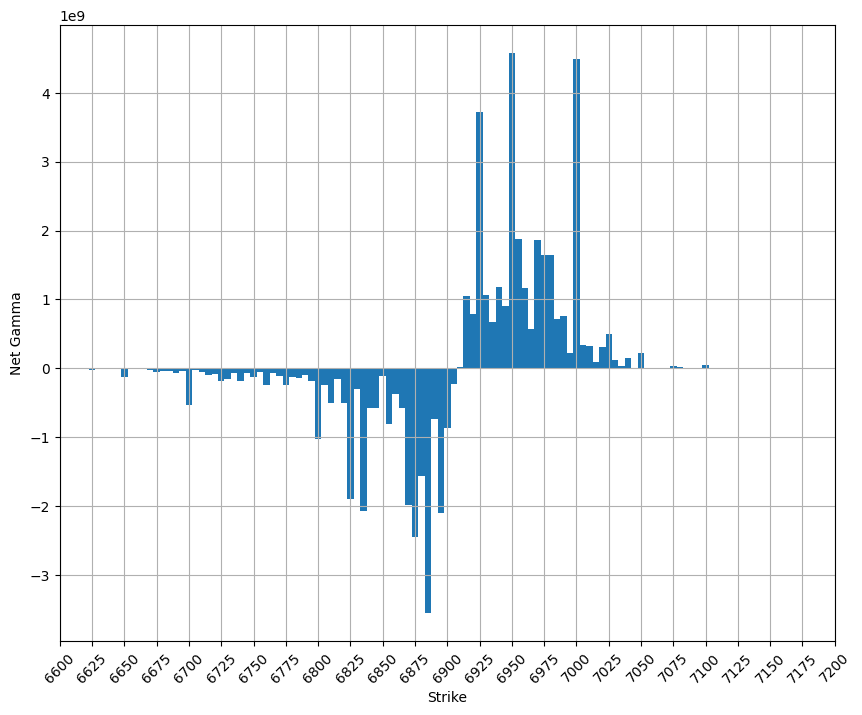

In [194]:
# order = np.argsort(call_strikes)
# call_strikes = call_strikes[order]
# net_gamma = net_gamma.iloc[order].values

fig, axs = plt.subplots(figsize=(10, 8))

axs.bar(net_gamma["strike"], net_gamma["net_gamma"], width=5)

axs.set_xlim(6600, 7200)

# ticks every 25 or 50 points
axs.set_xticks(np.arange(6600, 7200 + 1, 25))
axs.tick_params(axis="x", rotation=45)
axs.grid(True)
axs.set_xlabel("Strike")
axs.set_ylabel("Net Gamma")
plt.show()

## Net Gamma by Price

In [287]:
# NOTE: loading the option chains

symbol = "SPXW"
start_date = "2025-12-29"
days_out = 10
data_dir = Path("../data")

start_dt = datetime.strptime(start_date, "%Y-%m-%d")
end_dt = start_dt + timedelta(days=days_out)

months = [start_dt.month, (start_dt.month % 12) + 1]
years = [start_dt.year, start_dt.year if start_dt.month < 12 else start_dt.year + 1]

csv_files = []
for m, y in zip(months, years):
    month_str = f"{y:04d}-{m:02d}"
    pattern = f"{symbol}_exp{month_str}*.csv"
    csv_files.extend(sorted(data_dir.glob(pattern)))

if not csv_files:
    raise ValueError(f"No option chain CSV files found for symbol {symbol} in {self.data_dir}")

files_by_expiration = {}
for csv_file in csv_files:
    try:
        parts = csv_file.stem.split("_")
        if len(parts) >= 4:
            exp_date_str = parts[1].replace("exp", "")
            exp_date = datetime.strptime(exp_date_str, "%Y-%m-%d")

            fetch_date = parts[2]
            fetch_time = parts[3]
            fetch_dt = datetime.strptime(f"{fetch_date}_{fetch_time}", "%Y-%m-%d_%H-%M-%S")

            if start_dt <= exp_date <= end_dt:
                if (
                    exp_date_str not in files_by_expiration
                    or fetch_dt > files_by_expiration[exp_date_str][0]
                ):
                    files_by_expiration[exp_date_str] = (fetch_dt, csv_file)
    except Exception:
        continue

if not files_by_expiration:
    raise ValueError(
        f"No option chain files found with expirations between {start_date} and {end_dt.strftime('%Y-%m-%d')}"
    )

latest_files = [file_info[1] for file_info in files_by_expiration.values()]

dfs = []
for csv_file in latest_files:
    df_temp = pd.read_csv(csv_file)

    if not df_temp.empty:
        dfs.append(df_temp)


# NOTE: create the price grid
prices = set([strike for opt_chain in dfs for strike in opt_chain["strike"]])

In [288]:
# NOTE: calculate GEX by price
net_gammas = []
net_gamma_by_price = {}

for p in prices:
    net_gamma_by_price[p] = 0

    for opt_chain in dfs:
        call_opts = opt_chain[opt_chain["contract_type"] == "CALL"].reset_index(drop=True)
        put_opts = opt_chain[opt_chain["contract_type"] == "PUT"].reset_index(drop=True)

        call_gex = call_opts["gamma"] * call_opts["open_interest"] * p**2
        put_gex = put_opts["gamma"] * put_opts["open_interest"] * p**2
        net_gamma = call_gex.sum() - put_gex.sum()

        if net_gamma == np.nan:
            raise Exception("net gamma Nan")

        net_gamma_by_price[p] += net_gamma

price:  6145.0
<class 'numpy.float64'>
-6872431027.949997
<class 'numpy.float64'>
-1595063457.0250015
<class 'numpy.float64'>
16819780082.675003
<class 'numpy.float64'>
-895162858.6499996
<class 'numpy.float64'>
-83980519.5999999
<class 'numpy.float64'>
279922478.3249999
<class 'numpy.float64'>
118078725.17500007
<class 'numpy.float64'>
577743682.5000001
price:  4100.0
<class 'numpy.float64'>
-3059386380.0
<class 'numpy.float64'>
-710071210.0
<class 'numpy.float64'>
7487627870.0
<class 'numpy.float64'>
-398497860.0
<class 'numpy.float64'>
-37385440.0
<class 'numpy.float64'>
124612530.0
<class 'numpy.float64'>
52564870.0
<class 'numpy.float64'>
257193000.0
price:  6150.0
<class 'numpy.float64'>
-6883619355.0
<class 'numpy.float64'>
-1597660222.5
<class 'numpy.float64'>
16847162707.5
<class 'numpy.float64'>
-896620185.0
<class 'numpy.float64'>
-84117240.0
<class 'numpy.float64'>
280378192.5
<class 'numpy.float64'>
118270957.5
<class 'numpy.float64'>
578684250.0
price:  8200.0
<class 'num

In [289]:
# NOTE: util functions
def norm_pdf(x):
    return np.exp(-0.5 * x * x) / np.sqrt(2.0 * np.pi)


def bs_gamma(S, K, T, sigma, r=0.0, q=0.0):
    eps = 1e-12
    S = np.maximum(S, eps)
    K = np.maximum(K, eps)
    T = np.maximum(T, eps)
    sigma = np.maximum(sigma, eps)

    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return norm_pdf(d1) / (S * sigma * np.sqrt(T))

In [302]:
# --- flatten chains ---
all_opts = pd.concat(dfs, ignore_index=True).copy()

# Use snapshot time if you have it; otherwise use start_date 09:45 CT as a reasonable intraday "asof"
# NOTE: check the CSV files for the latest timestamp or track the earliest timestamp while loading the
# the option chains
asof = datetime.strptime(start_date, "%Y-%m-%d").replace(hour=14, minute=5, second=0)

# NOTE: add 16 hours to get the end of the day
all_opts["expiration_dt"] = pd.to_datetime(all_opts["expiration_date"]) + pd.Timedelta(hours=16)

# Time to expiry in years; for same-day expiries, this will be tiny/near-zero, so floor it
all_opts["T"] = (all_opts["expiration_dt"] - asof).dt.total_seconds() / (365.0 * 24 * 3600)
all_opts["T"] = all_opts["T"].clip(lower=(1.0 / (365.0 * 24 * 60)))  # floor at ~1 minute

# --- IV: use theoretical_volatility, convert percent -> decimal
if "theoretical_volatility" not in all_opts.columns:
    raise ValueError("Expected theoretical_volatility column for IV input.")

all_opts["iv"] = pd.to_numeric(all_opts["theoretical_volatility"], errors="coerce") / 100.0

# Clean numeric columns
all_opts["K"] = pd.to_numeric(all_opts["strike"], errors="coerce")
all_opts["OI"] = pd.to_numeric(all_opts["open_interest"], errors="coerce")

# Filter valid rows
all_opts = all_opts.dropna(subset=["iv", "K", "OI", "T"])
all_opts = all_opts[(all_opts["iv"] > 0) & (all_opts["OI"] > 0)].copy()

is_call = (all_opts["contract_type"] == "CALL").to_numpy()
K = all_opts["K"].to_numpy(dtype=float)
T = all_opts["T"].to_numpy(dtype=float)
iv = all_opts["iv"].to_numpy(dtype=float)
OI = all_opts["OI"].to_numpy(dtype=float)

spot = float(pd.to_numeric(all_opts["underlying_price"], errors="coerce").dropna().iloc[0])

# Price grid (don’t use strikes as prices)
prices_grid = np.arange(round(spot) - 300, round(spot) + 301, 1)

net_gex_by_price = {}

for p in prices_grid:
    S = np.full_like(K, float(p), dtype=float)

    gam = bs_gamma(S=S, K=K, T=T, sigma=iv, r=0.0, q=0.0)

    # "GEX-ish" scaling like your current code (NOT dollar GEX yet):
    gex_each = gam * OI * (float(p) ** 2)

    net_gex = gex_each[is_call].sum() - gex_each[~is_call].sum()
    net_gex_by_price[float(p)] = float(net_gex)

slope:  705644482.3544235
scaled slope:  70.56444823544236


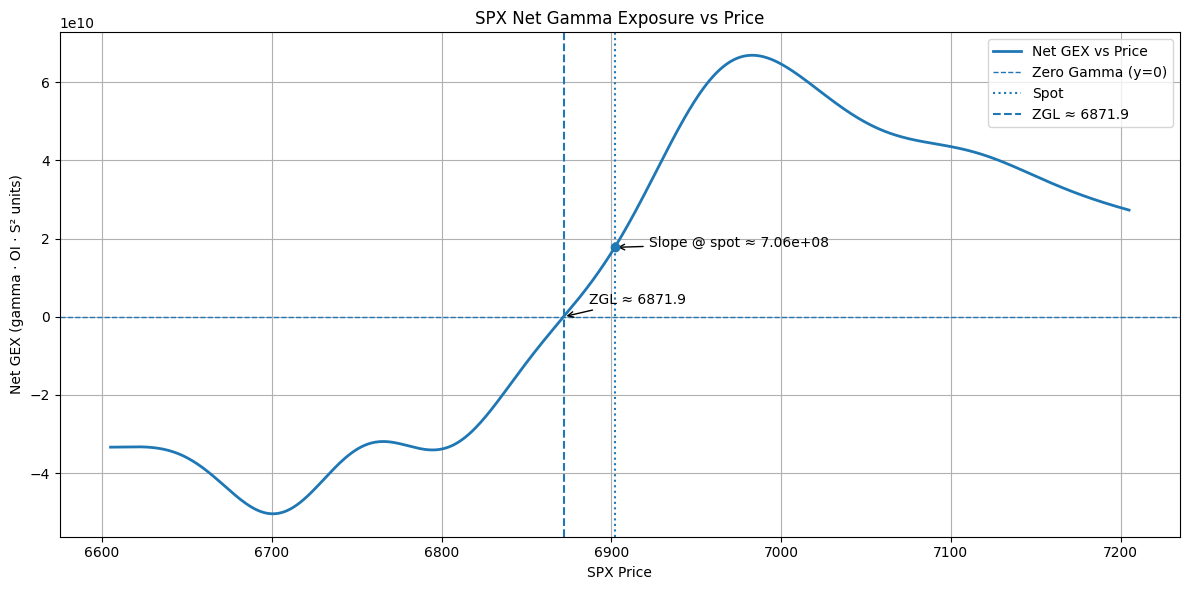

In [303]:
prices = np.array(sorted(net_gex_by_price.keys()))
gex = np.array([net_gex_by_price[p] for p in prices])

# arrays
prices = np.array(sorted(net_gex_by_price.keys()), dtype=float)
gex = np.array([net_gex_by_price[p] for p in prices], dtype=float)

# --- find zero-gamma crossing (linear interpolation) ---
sign = np.sign(gex)
idx = np.where(np.diff(sign) != 0)[0]  # indices where sign changes

zgl = None
if len(idx) > 0:
    i = idx[0]  # first crossing (usually the main one)
    x1, x2 = prices[i], prices[i + 1]
    y1, y2 = gex[i], gex[i + 1]
    zgl = x1 + (0 - y1) * (x2 - x1) / (y2 - y1)

# --- plot ---
plt.figure(figsize=(12, 6))
plt.plot(prices, gex, linewidth=2, label="Net GEX vs Price")
plt.axhline(0, linestyle="--", linewidth=1, label="Zero Gamma (y=0)")

spot = 6902.18  # replace
plt.axvline(spot, linestyle=":", linewidth=1.5, label="Spot")


if zgl is not None:
    plt.axvline(zgl, linestyle="--", linewidth=1.5, label=f"ZGL ≈ {zgl:.1f}")
    plt.annotate(
        f"ZGL ≈ {zgl:.1f}",
        xy=(zgl, 0),
        xytext=(zgl + 15, gex.max() * 0.05),
        arrowprops=dict(arrowstyle="->"),
    )

i = np.argmin(np.abs(prices - spot))

# guard against edges
if 0 < i < len(prices) - 1:
    slope = (gex[i + 1] - gex[i - 1]) / (prices[i + 1] - prices[i - 1])
else:
    slope = np.nan

print("slope: ", slope)
print("scaled slope: ", slope * 100 / 1e9)

plt.scatter(prices[i], gex[i], zorder=5)
plt.annotate(
    f"Slope @ spot ≈ {slope:,.2e}",
    xy=(prices[i], gex[i]),
    xytext=(prices[i] + 20, gex[i]),
    arrowprops=dict(arrowstyle="->"),
)

plt.xlabel("SPX Price")
plt.ylabel("Net GEX (gamma · OI · S² units)")
plt.title("SPX Net Gamma Exposure vs Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [265]:
target_price = spot  # or zgl

S = np.full(len(all_opts), float(target_price))

gam = bs_gamma(
    S=S,
    K=all_opts["strike"].to_numpy(dtype=float),
    T=all_opts["T"].to_numpy(dtype=float),
    sigma=all_opts["iv"].to_numpy(dtype=float),
    r=0.0,
    q=0.0,
)

gex_each = gam * all_opts["open_interest"].to_numpy(dtype=float) * (target_price**2)

signed_gex = np.where(all_opts["contract_type"] == "CALL", gex_each, -gex_each)

# --- new dataframe ---
gex_contrib_df = all_opts[["contract_type", "expiration_date", "strike", "open_interest"]].copy()

gex_contrib_df["gamma_at_price"] = gam
gex_contrib_df["signed_gex"] = signed_gex
gex_contrib_df["abs_gex"] = np.abs(signed_gex)

In [278]:
pd.set_option("display.max_rows", 1000)

In [281]:
(
    gex_contrib_df.groupby("strike", as_index=False)
    .agg(net_gex=("signed_gex", "sum"), abs_gex=("abs_gex", "sum"))
    .sort_values("abs_gex", ascending=False)
)

,strike,net_gex,abs_gex
418,6900.0,-6.316352e+09,2.692022e+10
438,7000.0,9.149975e+09,1.433327e+10
408,6850.0,1.812049e+08,6.783512e+09
428,6950.0,3.458495e+09,5.419903e+09
419,6905.0,-1.375702e+09,5.116998e+09
420,6910.0,-8.491537e+08,4.320402e+09
417,6895.0,-2.416936e+09,3.995101e+09
398,6800.0,-6.183366e+07,3.753416e+09
405,6835.0,-1.217244e+09,3.374505e+09
423,6925.0,2.233884e+09,3.197106e+09


## Plot Class

In [2]:
import sys

from trade_lab.charts import GEXPrice, GEXStrike

Loading 9 option chain files for GEX by Strike calculation.
Data as of 2026-01-13 10:18:28
../data/SPXW_exp2026-01-13_2026-01-13_10-18-28.csv
../data/SPXW_exp2026-01-14_2026-01-13_10-18-30.csv
../data/SPXW_exp2026-01-15_2026-01-13_10-18-31.csv
../data/SPXW_exp2026-01-16_2026-01-13_10-18-35.csv
../data/SPXW_exp2026-01-19_2026-01-13_10-18-36.csv
../data/SPXW_exp2026-01-20_2026-01-13_10-18-37.csv
../data/SPXW_exp2026-01-21_2026-01-13_10-18-39.csv
../data/SPXW_exp2026-01-22_2026-01-13_10-18-40.csv
../data/SPXW_exp2026-01-23_2026-01-13_10-18-42.csv
Calculated GEX for 440 unique strikes
Loading 9 option chain files for GEX by Price calculation.
Data as of 2026-01-13 10:18:28
../data/SPXW_exp2026-01-13_2026-01-13_10-18-28.csv
../data/SPXW_exp2026-01-14_2026-01-13_10-18-30.csv
../data/SPXW_exp2026-01-15_2026-01-13_10-18-31.csv
../data/SPXW_exp2026-01-16_2026-01-13_10-18-35.csv
../data/SPXW_exp2026-01-19_2026-01-13_10-18-36.csv
../data/SPXW_exp2026-01-20_2026-01-13_10-18-37.csv
../data/SPXW_exp

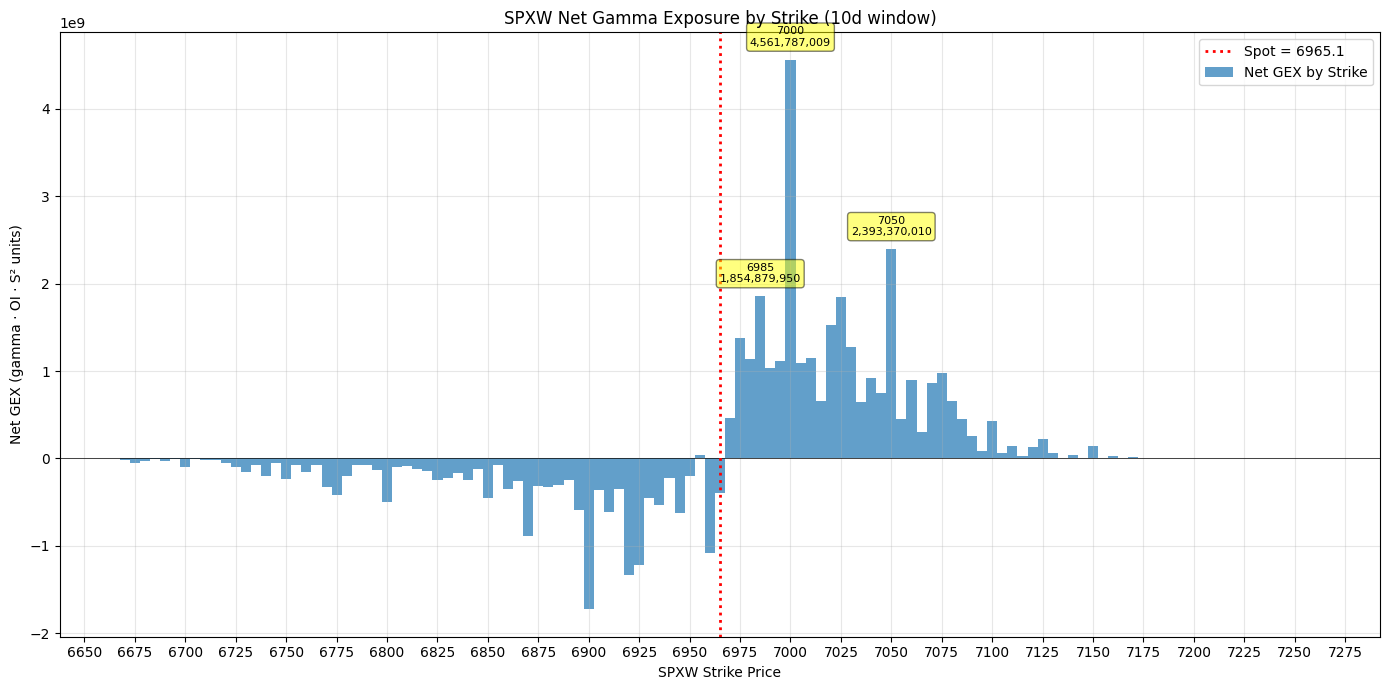

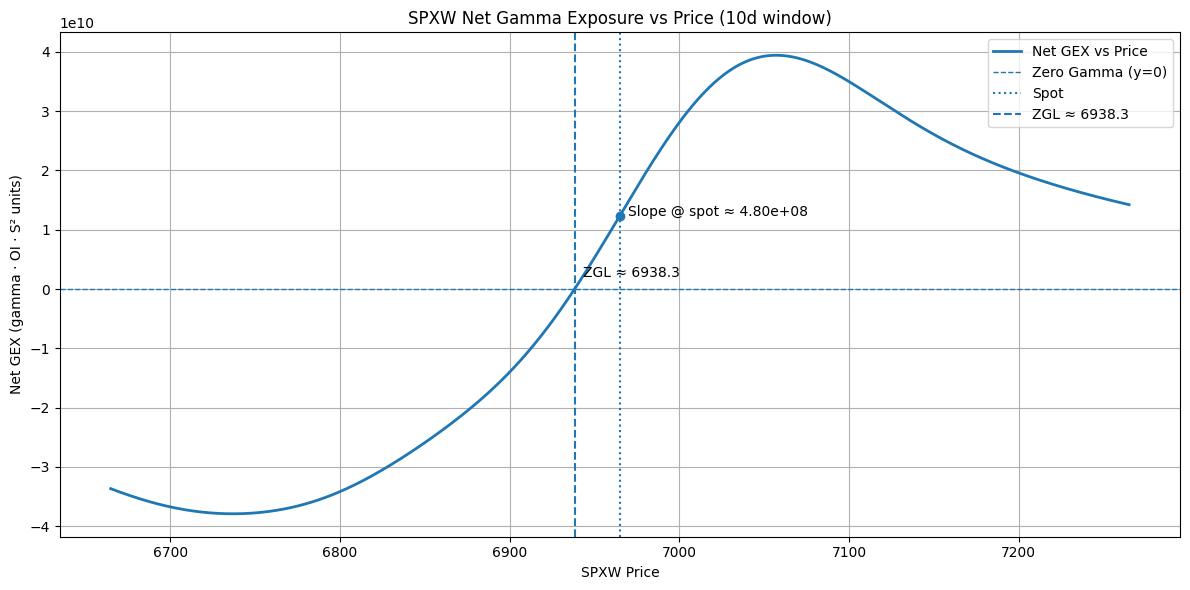

In [3]:
start_date = "2026-01-13"
gex_strike = GEXStrike(symbol="SPXW", start_date=start_date, data_dir="../data", debug=True)
gex_strike.load_data()
fig, ax = gex_strike.plot()

gex_price = GEXPrice(symbol="SPXW", start_date=start_date, data_dir="../data", debug=True)
gex_price.load_data()
fig, ax = gex_price.plot()

Loading 7 option chain files for GEX by Price calculation.
Data as of 2026-01-07 15:08:06
../data/SPXW_exp2026-01-08_2026-01-07_15-08-06.csv
../data/SPXW_exp2026-01-09_2026-01-07_15-08-07.csv
../data/SPXW_exp2026-01-12_2026-01-07_15-08-09.csv
../data/SPXW_exp2026-01-13_2026-01-07_15-08-11.csv
../data/SPXW_exp2026-01-14_2026-01-07_15-08-12.csv
../data/SPXW_exp2026-01-15_2026-01-07_15-08-14.csv
../data/SPXW_exp2026-01-16_2026-01-07_15-08-18.csv
Calculating GEX on price grid from 6621 to 7221
crossings found at indices:  [254]


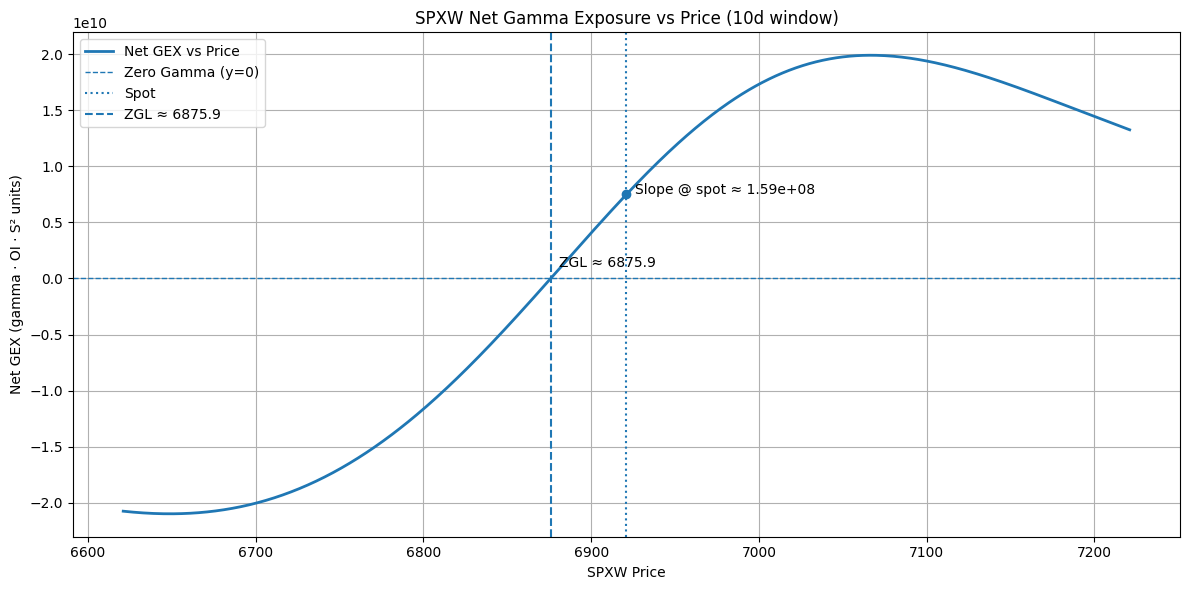

In [129]:
gex_price = GEXPrice(symbol="SPXW", start_date="2026-01-08", data_dir="../data", debug=True)
gex_price.load_data()
fig, ax = gex_price.plot()

Loading 7 option chain files for GEX by Price calculation.
Data as of 2026-01-06 12:21:20
../data/SPXW_exp2026-01-08_2026-01-06_12-21-20.csv
../data/SPXW_exp2026-01-09_2026-01-06_12-21-21.csv
../data/SPXW_exp2026-01-12_2026-01-06_12-21-22.csv
../data/SPXW_exp2026-01-13_2026-01-06_12-21-23.csv
../data/SPXW_exp2026-01-14_2026-01-06_12-21-25.csv
../data/SPXW_exp2026-01-15_2026-01-06_12-21-26.csv
../data/SPXW_exp2026-01-16_2026-01-06_12-21-29.csv
Calculating GEX on price grid from 6637 to 7237
crossings found at indices:  [248]


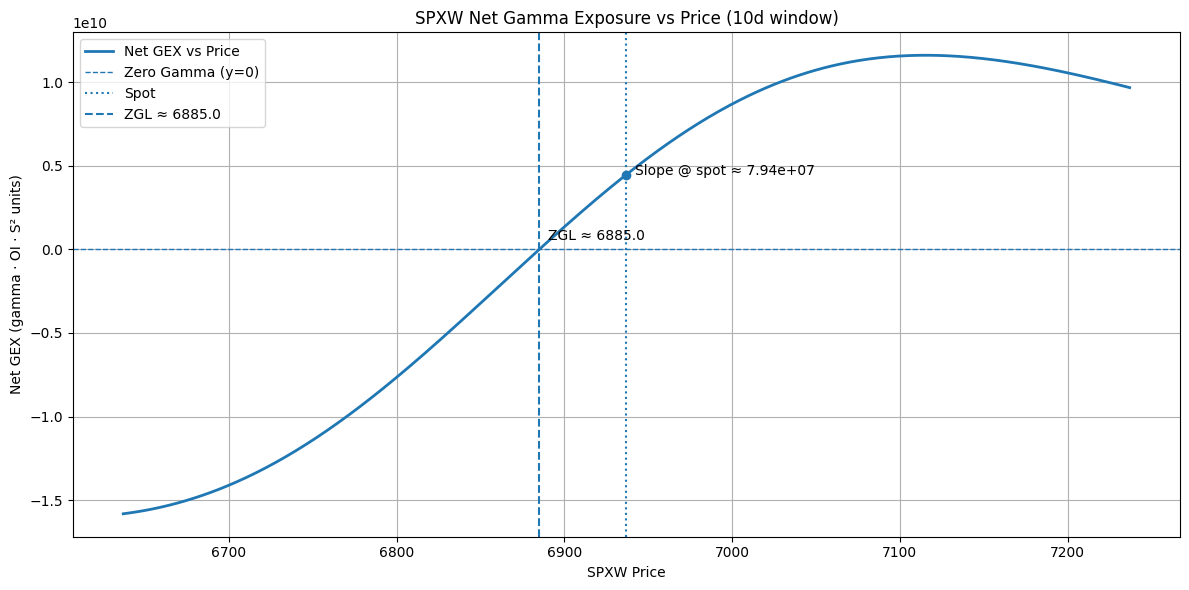

In [106]:
gex_price = GEXPrice(symbol="SPXW", start_date="2026-01-08", data_dir="../data", debug=True)
gex_price.load_data()
fig, ax = gex_price.plot()